# Load Tether Analysis Dataframe

This notebook demonstrates how to load and work with tether analysis data exported in XArray format from the PyFMGUI DyNaMo tether analysis tool.

The notebook covers:
1. Loading session data from NetCDF files
2. Loading analysis results from NetCDF files 
3. Basic data exploration and visualization
4. Working with the structured scientific data format

In [1]:
# Import required libraries
# import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from plotly.subplots import make_subplots
import plotly.graph_objects as go

import plotly.express as px



In [2]:
# open csv file as dataframe
csv_file_path = '/Users/evillz/Data/article/2025_07_01_THP1_phd/sessions/batch_analysis_results/detailed_plateau_data.csv'
csv_file_path = '/Users/evillz/Data/article/2025_07_01_THP1_phd/sessions/velocity_normalized_thp1_cell1/batch_analysis_results/detailed_plateau_data.csv'
csv_file_path = '/Users/evillz/Data/article/final_yey/batch_analysis_results/detailed_plateau_data.csv'
csv_file_path = '/Users/evillz/Data/article/final_yey/final/yess/batch_analysis_results/detailed_plateau_data.csv'

df = pd.read_csv(csv_file_path)


In [3]:
# Cycle through file_idx and plateau_idx, get delta_avg for selected plateaus
# Set N to control how many of the last plateaus to analyze per file
N =1  # Change this value to get the last N plateaus
N_end_offset = 0
N_start_offset = 1


selected_delta_avg = []
unselected_delta_avg = []
selected_velocity_meta = []
unselected_velocity_meta = []
selected_delta_time = []
selected_slope= []
selected_tether_lifetime_m = []
selected_tether_lifetime_s = []
loading_rate = []
rupture_slope_arr = []
# Group by file_idx to process each file
for file_idx in df['file_idx'].unique():
    file_data = df[df['file_idx'] == file_idx]
    filename = file_data['filename'].iloc[0]  # Get filename for this file_idx
    
    print(f"\nFile {file_idx}: {filename}")
    
    # Get unique plateau indices and sort them to get the last N
    plateau_indices = sorted(file_data['plateau_idx'].unique())
    num_plateaus = len(plateau_indices)
    
    if num_plateaus == 6:
        print ('yes')

    if num_plateaus-1 <= 1:
        num_plateaus = 0
    else: 
        num_plateaus = num_plateaus - N - 1  # Adjust for start offset

    # last_n_plateaus = plateau_indices[-N-1:-N] if len(plateau_indices) >= N else plateau_indices
    last_n_plateaus = plateau_indices[:num_plateaus:-1]
    
    print(f"  Total plateaus: {len(plateau_indices)}, analyzing last {len(last_n_plateaus)} plateaus: {last_n_plateaus}")
    
    # Cycle through only the last N plateaus in this file
    for plateau_idx in last_n_plateaus:
        plateau_data = file_data[file_data['plateau_idx'] == plateau_idx]
        
        if len(plateau_data) > 0:
            row = plateau_data.iloc[0]  # Get the plateau data
            delta_avg = row['delta_avg'] # tether force
            plateau_selected = row['plateau_selected']
            plateau_delta_time = np.round(row['delta_time']) # time for tethering to occur starting from contact point
            plateau_loading_rate = row['mean dN/dt']  #mean derivate dF/dZ 
            plateau_velocity_calc = row['plateau_velocity_calc']  # calculated velocity
            meta_velocity = int(np.round(row['velocity_metadata'])) 
            plateau_velocity_meta = meta_velocity if plateau_velocity_calc == np.nan or 0 else plateau_velocity_calc # metadata velocity1
            # plateau_velocity_meta = int(np.round(row['velocity_metadata'])) # metadata velocity1
            plateau_slope = row['slope']  # Slope of plateau
            plateau_avg_idx = row['plateau_avg']  # index of plateau average value within the plateau
            tether_lifeime_s = row['tether_lifetime_s']  # duration of a plateau in seconds
            rupture_slope = row['rupture_slope']  # Slope of rupture segment
            
            print(f"  Plateau {plateau_idx}: delta_avg={delta_avg:.2e}, selected={plateau_selected}, \
                    delta_time={plateau_delta_time:.2f}, mean_derivative={plateau_loading_rate:.2e}, \
                    velocity_calc={plateau_velocity_calc:.2e}, velocity_meta={plateau_velocity_meta}")
            
            # Store delta_avg and velocity_metadata based on selection status
            if plateau_selected:
                # store items back into dataframe
                df.loc[plateau_data.index, 'selected_delta_avg'] = delta_avg
                df.loc[plateau_data.index, 'selected_velocity_meta'] =plateau_velocity_meta
                df.loc[plateau_data.index, 'selected_delta_time'] = plateau_delta_time
                df.loc[plateau_data.index, 'selected_slope'] = plateau_slope
                df.loc[plateau_data.index, 'selected_tether_lifetime_m'] = row['tether_lifetime_m']
                df.loc[plateau_data.index, 'selected_tether_lifetime_s'] = tether_lifeime_s 
                df.loc[plateau_data.index, 'loading_rate'] = plateau_loading_rate
                df.loc[plateau_data.index, 'rupture_slope'] = rupture_slope

                # Create lists for selected values
                # Append NaN if any value is exactly zero, else append the value
                selected_delta_avg.append(np.nan if delta_avg == 0 else delta_avg) #Delta F of average force of plateau
                selected_velocity_meta.append(np.nan if plateau_velocity_meta == 0 else -plateau_velocity_meta) # velocity at plteau
                selected_delta_time.append(np.nan if plateau_delta_time == 0 else plateau_delta_time) # time of each plateau 
                selected_slope.append(np.nan if plateau_slope == 0 else plateau_slope) #slope of plateau segment df/dz
                selected_tether_lifetime_m.append(np.nan if row['tether_lifetime_m'] == 0 else row['tether_lifetime_m']) # Detachment tie 
                selected_tether_lifetime_s.append(np.nan if tether_lifeime_s == 0 else tether_lifeime_s) #time of each tether plateau from contact point 
                loading_rate.append(np.nan if plateau_loading_rate == 0 else plateau_loading_rate)
                rupture_slope_arr.append(np.nan if rupture_slope == 0 else rupture_slope)
            else:
                unselected_delta_avg.append(delta_avg)
                unselected_velocity_meta.append(plateau_velocity_meta)




File 1: fcurve_THP1_canti2_day2_100ums__2025.07.02_12.32.34.68.tdms
  Total plateaus: 4, analyzing last 1 plateaus: [np.int64(3)]
  Plateau 3: delta_avg=-4.94e-11, selected=True,                     delta_time=0.00, mean_derivative=9.21e-10,                     velocity_calc=-8.09e+01, velocity_meta=-80.9014813181329

File 2: fcurve_THP1_canti2_day2_100ums__2025.07.02_12.33.12.98.tdms
yes
  Total plateaus: 6, analyzing last 1 plateaus: [np.int64(5)]
  Plateau 5: delta_avg=-1.09e-11, selected=True,                     delta_time=0.00, mean_derivative=8.78e-10,                     velocity_calc=-7.54e+01, velocity_meta=-75.43221059069418

File 3: fcurve_THP1_canti2_day2_100ums__2025.07.02_12.32.20.70.tdms
  Total plateaus: 3, analyzing last 1 plateaus: [np.int64(2)]
  Plateau 2: delta_avg=-2.52e-11, selected=True,                     delta_time=0.00, mean_derivative=8.55e-10,                     velocity_calc=-7.62e+01, velocity_meta=-76.18395186403492

File 4: fcurve_THP1_canti2_day2_1

## Variable Summary

| Variable Name                | Description                                                                                 | Units                |
|------------------------------|--------------------------------------------------------------------------------------------|----------------------|
| `selected_delta_avg`         | List of average tether force values for selected plateaus                                  | Newtons (N)          |
| `selected_velocity_meta`     | List of velocity metadata values for selected plateaus                                     | µm/s                 |
| `selected_delta_time`        | List of plateau segment duration                                                           | seconds (s)          |
| `selected_slope`             | List of plateau slopes (dF/dZ) for selected plateaus                                       | N/m                  |
| `selected_tether_lifetime_m` | List of detachment distances for selected plateaus                                         | meters (m)           |
| `selected_tether_lifetime_s` | List of tether lifetimes for selected plateaus                                             | seconds (s)          |
| `loading_rate`               | loading rates (mean dF/dt) for selected plt where df=force (N),dt = dt*velocity_um_s       | N/s                  |
| `rupture_slope_arr`          | List of rupture slopes for selected plateaus                                               | N/m                  |
| `velocity_meta_clean`        | Numpy array of selected velocities, cleaned of NaN and zero values                        | µm/s                 |
| `delta_avg_clean`            | Numpy array of selected average forces, cleaned of NaN and zero values                    | Newtons (N)          |
| `force_valid_mask`           | Boolean mask for valid force/velocity data (non-NaN, non-zero, within force range)         | -                    |
| `velocity_force_filtered`    | Filtered velocities after applying `force_valid_mask`                                      | µm/s                 |
| `force_filtered`             | Filtered forces after applying `force_valid_mask`                                          | Newtons (N)          |
| `velocity_log`               | Log10 of filtered velocities                                                               | log10(µm/s)          |
| `force_log`                  | Filtered forces converted to pN                                                            | pN                   |
| `finite_mask`                | Boolean mask for finite log values                                                         | -                    |
| `velocity_log_clean`         | Cleaned log10 velocities (finite only)                                                     | log10(µm/s)          |
| `force_log_clean`            | Cleaned force values in pN (finite only)                                                   | pN                   |
| `force_df`                   | DataFrame containing filtered and cleaned velocity and force data                          | -                    |
| `means_df`                   | DataFrame containing mean force and velocity per velocity bin                              | -                    |
| `tether_force_array`         | Absolute value of selected delta_avg as numpy array                                        | Newtons (N)          |
| `tether_lifetime_s_array`    | Numpy array of selected tether lifetimes (seconds)                                         | seconds (s)          |
| `tether_lifetime_m_array`    | Numpy array of selected detachment distances (meters)                                      | meters (m)           |
| `loading_rate_array`         | Numpy array of loading rates                                                               | N/s                  |
| `tether_force_bin_labels_for_points` | List of force bin labels for each point (for binned plotting)                      | pN                   |
| `loading_rate_bin_labels_for_points` | List of loading rate bin labels for each point (for binned plotting)               | pN/s                 |

In [4]:
# Filter out detachment times and their respective velocities that are in the order of 1e-6 seconds
filtered_df = df[df['delta_time'] > 1e-6]   

# Filter out detachment times smaller than 1e-6 seconds and create boxplot
selected_tether_lifetime_s_array = np.array(selected_tether_lifetime_s)
selected_velocity_meta_array = np.array(selected_velocity_meta)
selected_rupture_slope = np.array(rupture_slope_arr)

# Create mask for times >= 1e-6 seconds
time_filter_mask = selected_tether_lifetime_s_array >= 1e-5

# Apply filter to both arrays
filtered_tether_lifetime_s_array = selected_tether_lifetime_s_array[time_filter_mask]
filtered_velocity_meta = selected_velocity_meta_array[time_filter_mask]

# Remove NaN values
valid_mask = ~(np.isnan(filtered_tether_lifetime_s_array) | np.isnan(filtered_velocity_meta))
filtered_tether_lifetime_s_array_nan = filtered_tether_lifetime_s_array[valid_mask]
filtered_velocity_meta_clean = selected_velocity_meta_array[valid_mask]

# 5. Tether detachment distance vs binned extraction force in ascending order, with loading rates sorted accordingly
tether_force_array = np.abs(np.array(selected_delta_avg)) 
tether_lifetime_s_array = np.array(selected_tether_lifetime_s) 
tether_lifetime_m_array = np.array(selected_tether_lifetime_m)  
loading_rate_array = np.array(loading_rate)
rupture_slope_array = np.array(selected_rupture_slope)

# Remove NaN values from all arrays before binning
valid_mask = ~(np.isnan(tether_force_array) | np.isnan(tether_lifetime_s_array) | np.isnan(loading_rate_array))
tether_force_array_clean = tether_force_array[valid_mask]
tether_lifetime_s_array_clean = tether_lifetime_s_array[valid_mask]
tether_lifetime_m_array_clean = tether_lifetime_m_array[valid_mask]
loading_rate_array_clean = loading_rate_array[valid_mask]
rupture_slope_array_clean = rupture_slope_array[valid_mask] 

# Sort force in ascending order
sorted_indices = np.argsort(tether_force_array_clean)
tether_force_array_sorted = tether_force_array_clean[sorted_indices]

# sort tether force in ascending order
sorted_tether_force_indices = np.argsort(tether_force_array_sorted)
tether_force_array_sorted = tether_force_array_sorted[sorted_tether_force_indices]

# Sort tether lifetime s in ascending order
sorted_tether_lifetime_s_indices = np.argsort(tether_lifetime_s_array_clean)
tether_lifetime_s_array_sorted = tether_lifetime_s_array_clean[sorted_tether_lifetime_s_indices]

# sort tether lifetime m in ascending order
sorted_tether_lifetime_m_indices = np.argsort(tether_lifetime_m_array_clean)
tether_lifetime_m_array_sorted = tether_lifetime_m_array_clean[sorted_tether_lifetime_m_indices]

#  Sort loading rate in ascending order
sorted_loading_rate_indices = np.argsort(loading_rate_array_clean)
loading_rate_sorted = loading_rate_array_clean[sorted_loading_rate_indices]

# Choose number of bins (e.g., 4 bins)
num_bins = 3
# FOR BINNING TETHER FORCE: delta_avg

# Bin the sorted forces into quantiles
force_bins_N = np.quantile(tether_force_array_sorted, np.linspace(0, 1, num_bins + 1))
# Fix: Convert to pN for readable labels and use scientific notation
force_bins_pN = force_bins_N * 1e12
force_bin_labels = [f"{force_bins_pN[i]:.1f}-{force_bins_pN[i+1]:.1f} pN" for i in range(num_bins)]

# Assign each force to a bin - FIXED: use all bins, not bins[1:]
tether_force_bin_indices = np.digitize(tether_force_array_sorted, force_bins_N, right=False)
# Convert to 0-based indexing and clip to valid range
tether_force_bin_indices = np.clip(tether_force_bin_indices - 1, 0, num_bins - 1)
tether_force_bin_labels_for_points = [force_bin_labels[i] for i in tether_force_bin_indices]

# FOR BINNING LOADING RATES

# Bin the loading rates into quantiles (optional: same number of bins)
loading_rate_bins = np.quantile(loading_rate_sorted, np.linspace(0, 1, num_bins + 1))
# Fix: Convert to pN/s for readable labels
loading_rate_bins_pN_s = loading_rate_bins * 1e12
loading_rate_bin_labels = [
    f"{loading_rate_bins_pN_s[i]:.1f}-{loading_rate_bins_pN_s[i+1]:.1f} pN/s"
    for i in range(num_bins)
]

# Assign each loading rate to a bin - FIXED: use all bins, not bins[1:]
loading_rate_bin_indices = np.digitize(loading_rate_sorted, loading_rate_bins, right=False)
# Convert to 0-based indexing and clip to valid range
loading_rate_bin_indices = np.clip(loading_rate_bin_indices - 1, 0, num_bins - 1)
loading_rate_bin_labels_for_points = [
    loading_rate_bin_labels[i] for i in loading_rate_bin_indices
]

In [5]:
# Check for negative values in selected_distance_detachment
has_negative = any(val < 0 for val in selected_tether_lifetime_m)
print("Contains negative values:", has_negative)

Contains negative values: False


In [6]:
# QUICK DIAGNOSIS - Test the plotting logic directly
velocity_meta_clean = np.array(selected_velocity_meta)
slope_clean = np.array(selected_slope)

main_valid_mask = (
    ~np.isnan(velocity_meta_clean) & 
    ~np.isnan(slope_clean) &
    (velocity_meta_clean != 0) &
    (slope_clean != 0)
)

velocity_filtered = velocity_meta_clean[main_valid_mask]
slope_filtered = slope_clean[main_valid_mask]

vel_bins_all = np.unique(np.round(velocity_filtered).astype(int))
print(f"Available velocity bins: {vel_bins_all}")

# Test slope plotting logic
slope_data_by_vel = []
vel_labels_slope = []
for v in vel_bins_all:
    mask = np.round(velocity_filtered).astype(int) == v
    slope_subset = slope_filtered[mask]
    slope_log = np.log10(np.abs(slope_subset) * 1e6)
    slope_valid = slope_log[np.isfinite(slope_log)]
    print(f"Velocity {v}: {len(slope_subset)} raw, {len(slope_valid)} valid slope values")
    if len(slope_valid) > 0:
        slope_data_by_vel.append(slope_valid)
        vel_labels_slope.append(v)

print(f"Final slope plot will have {len(vel_labels_slope)} velocity bins: {vel_labels_slope}")

# Same for distance
lifetime_m_clean = np.array(selected_tether_lifetime_m)
main_valid_mask_dist = (
    ~np.isnan(velocity_meta_clean) & 
    ~np.isnan(lifetime_m_clean) &
    (velocity_meta_clean != 0) &
    (lifetime_m_clean > 0)
)

velocity_dist_filtered = velocity_meta_clean[main_valid_mask_dist]
lifetime_m_filtered = lifetime_m_clean[main_valid_mask_dist]

distance_data_by_vel = []
vel_labels_distance = []
for v in vel_bins_all:
    mask = np.round(velocity_dist_filtered).astype(int) == v
    distance_subset = lifetime_m_filtered[mask]
    distance_log = np.log10(distance_subset * 1e6)
    distance_valid = distance_log[np.isfinite(distance_log)]
    print(f"Velocity {v}: {len(distance_subset)} raw, {len(distance_valid)} valid distance values")
    if len(distance_valid) > 0:
        distance_data_by_vel.append(distance_valid)
        vel_labels_distance.append(v)

print(f"Final distance plot will have {len(vel_labels_distance)} velocity bins: {vel_labels_distance}")

Available velocity bins: [ -14  -11  -10    0    2    4    5    7    8    9   10   11   19   20
   21   22   23   24   25   26   27   28   29   31   32   38   42   43
   44   45   46   47   48   58   61   62   66   67   69   70   71   72
   73   74   75   76   77   78   79   80   81   82   83   84   85   86
   87   88   89   90   91   93   95   96   97   98  100  103  105  106
  108  112  118  124  125  144  408  561  568  577  580  586  673  742
  761  785  798  799  812  825  844  863  875  878  882  944  957  961
 1030 1044 1065 1081 1086 1119 1154 1180 1211 1216 1240 1250 1258 1278
 1300 1303 1322 1324 1340 1352 1361 1366 1375 1382 1387 1403 1404 1435
 1437 1446 1447 1464 1473 1492 1497 1498 1499 1501 1505 1513 1514 1515
 1518 1523 1526 1527 1528 1530 1532 1534 1540 1545 1546 1551 1556 1561
 1566 1567 1568 1572 1574 1578 1579 1582 1588 1589 1590 1591 1593 1603
 1606 1609 1612 1615 1616 1618 1619 1620 1623 1625 1633 1634 1636 1650
 1651 1657 1659 1663 1664 1668 1673 1675 1679 1682 1

In [7]:
import matplotlib.pyplot as plt
import numpy as np

def safe_log10(data):
    """Compute log10 safely, avoiding -inf from zeros or negatives."""
    data = np.array(data, dtype=float)
    data[data <= 0] = np.nan
    return np.log10(data)

# Publication-style settings
plt.rcParams.update({
    'font.size': 11,
    'axes.linewidth': 1,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'axes.edgecolor': 'black',
})

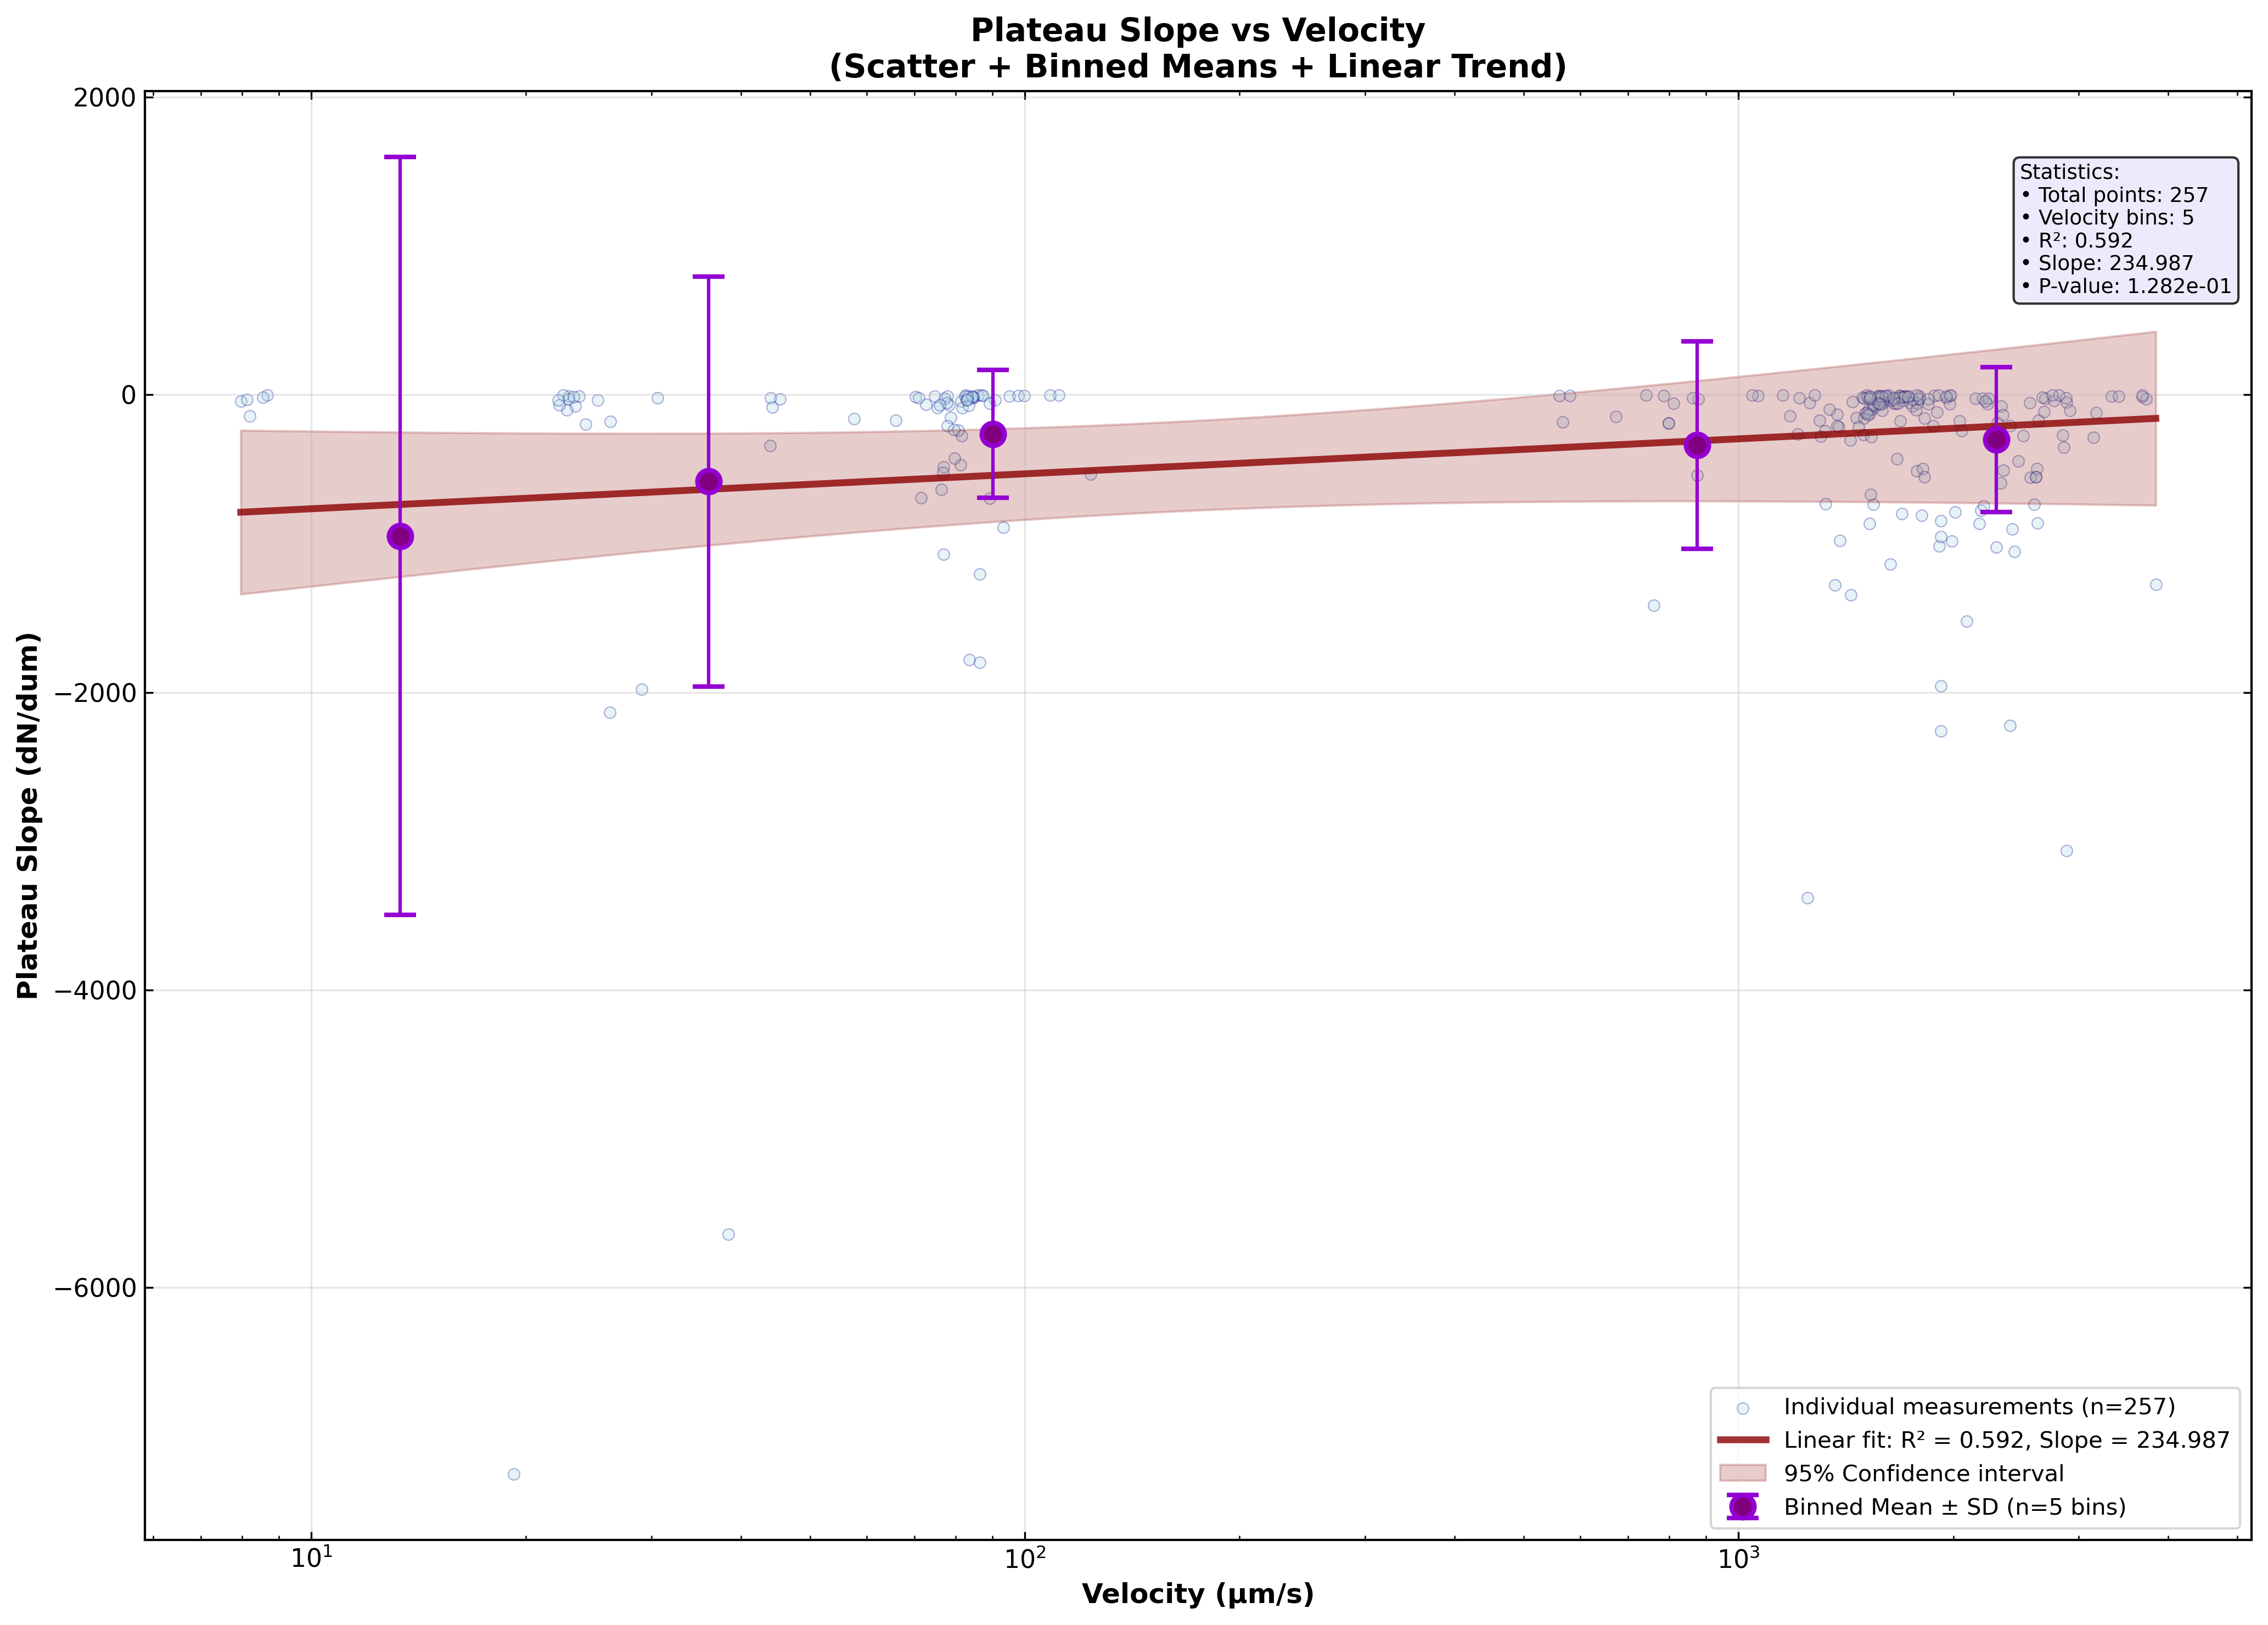

Slope analysis: 257 points, 5 bins


In [8]:
# 1. Plateau Slope vs Velocity (Combined Analysis with Binned Means)
import warnings
import scipy.stats as stats
from scipy import stats as scipy_stats
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Filter and prepare slope data
velocity_meta_clean = np.array(selected_velocity_meta)
slope_clean = np.array(selected_slope) * 1e6  # Convert to dN/dµm

# Basic data filtering
valid_mask = (
    ~np.isnan(velocity_meta_clean) & 
    ~np.isnan(slope_clean) &
    (velocity_meta_clean > 1e-6) &
    (slope_clean != 0) &
    (slope_clean < 1e-6 ) &
    (slope_clean < -1) 
)

velocity_filtered = velocity_meta_clean[valid_mask]
slope_filtered = slope_clean[valid_mask]
slope_log = slope_filtered  

# Remove infinite values
finite_mask = np.isfinite(slope_log)
velocity_filtered = velocity_filtered[finite_mask]
slope_log = slope_log[finite_mask]

# Create DataFrame
slope_df = pd.DataFrame({
    'velocity': velocity_filtered,
    'slope_log': slope_log
})

# Create main plot
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)

# 1. Scatter plot of all data points
ax.scatter(slope_df['velocity'], slope_df['slope_log'], 
          alpha=0.3, s=25, color='lightblue', edgecolors='darkblue', linewidth=0.5,
          label=f'Individual measurements (n={len(slope_df)})')

# 2. Create velocity bins and calculate means
num_bins = 6
velocity_min, velocity_max = slope_df['velocity'].min(), slope_df['velocity'].max()
bin_edges = np.logspace(np.log10(velocity_min), np.log10(velocity_max), num_bins + 1)

# Assign bins and calculate means
slope_df['bin_idx'] = np.digitize(slope_df['velocity'], bin_edges) - 1
slope_df['bin_idx'] = np.clip(slope_df['bin_idx'], 0, num_bins - 1)

means_df = slope_df.groupby('bin_idx').agg(
    velocity_center=('velocity', lambda x: np.sqrt(x.min() * x.max())),
    slope_mean=('slope_log', 'mean'),
    slope_std=('slope_log', 'std'),
    count=('slope_log', 'count')
).reset_index()

# Filter bins with enough data
means_df = means_df[means_df['count'] >= 3]

# 3. Plot means with error bars
if len(means_df) > 0:
    ax.errorbar(means_df['velocity_center'], means_df['slope_mean'], 
               yerr=means_df['slope_std'], 
               fmt='o', color='purple', markersize=10, markeredgecolor='darkviolet', 
               markeredgewidth=2, ecolor='darkviolet', capsize=7, capthick=2,
               label=f'Binned Mean ± SD (n={len(means_df)} bins)', zorder=5)

# 4. Fit linear trend to means
if len(means_df) >= 3:
    x_log = np.log10(means_df['velocity_center'])
    y_log = means_df['slope_mean']
    
    slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(x_log, y_log)
    
    # Generate and plot trend line
    x_trend = np.logspace(np.log10(velocity_min), np.log10(velocity_max), 100)
    y_trend = intercept + slope_coeff * np.log10(x_trend)
    
    ax.plot(x_trend, y_trend, 'darkred', linewidth=3, alpha=0.8,
           label=f'Linear fit: R² = {r_value**2:.3f}, Slope = {slope_coeff:.3f}')
    
    # Add confidence interval
    n = len(means_df)
    t_val = scipy_stats.t.ppf(0.975, n-2)
    residuals = y_log - (intercept + slope_coeff * x_log)
    mse = np.sum(residuals**2) / (n-2)
    
    x_log_trend = np.log10(x_trend)
    se_trend = np.sqrt(mse * (1/n + (x_log_trend - np.mean(x_log))**2 / 
                             np.sum((x_log - np.mean(x_log))**2)))
    
    ci_lower = y_trend - t_val * se_trend
    ci_upper = y_trend + t_val * se_trend
    
    ax.fill_between(x_trend, ci_lower, ci_upper, alpha=0.2, color='darkred',
                   label='95% Confidence interval')
else:
    slope_coeff, r_value, p_value = np.nan, np.nan, np.nan

# Formatting
ax.set_xlabel("Velocity (µm/s)", fontsize=12, fontweight='bold')
ax.set_ylabel("Plateau Slope (dN/dum)", fontsize=12, fontweight='bold')
ax.set_title("Plateau Slope vs Velocity\n(Scatter + Binned Means + Linear Trend)", 
            fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Statistics text
if not np.isnan(r_value):
    stats_text = f"""Statistics:
• Total points: {len(slope_df)}
• Velocity bins: {len(means_df)}
• R²: {r_value**2:.3f}
• Slope: {slope_coeff:.3f}
• P-value: {p_value:.3e}"""
else:
    stats_text = f"""Statistics:
• Total points: {len(slope_df)}
• Insufficient data for trend"""

ax.text(0.89, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lavender', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Slope analysis: {len(slope_df)} points, {len(means_df)} bins")

<Figure size 4200x3000 with 0 Axes>

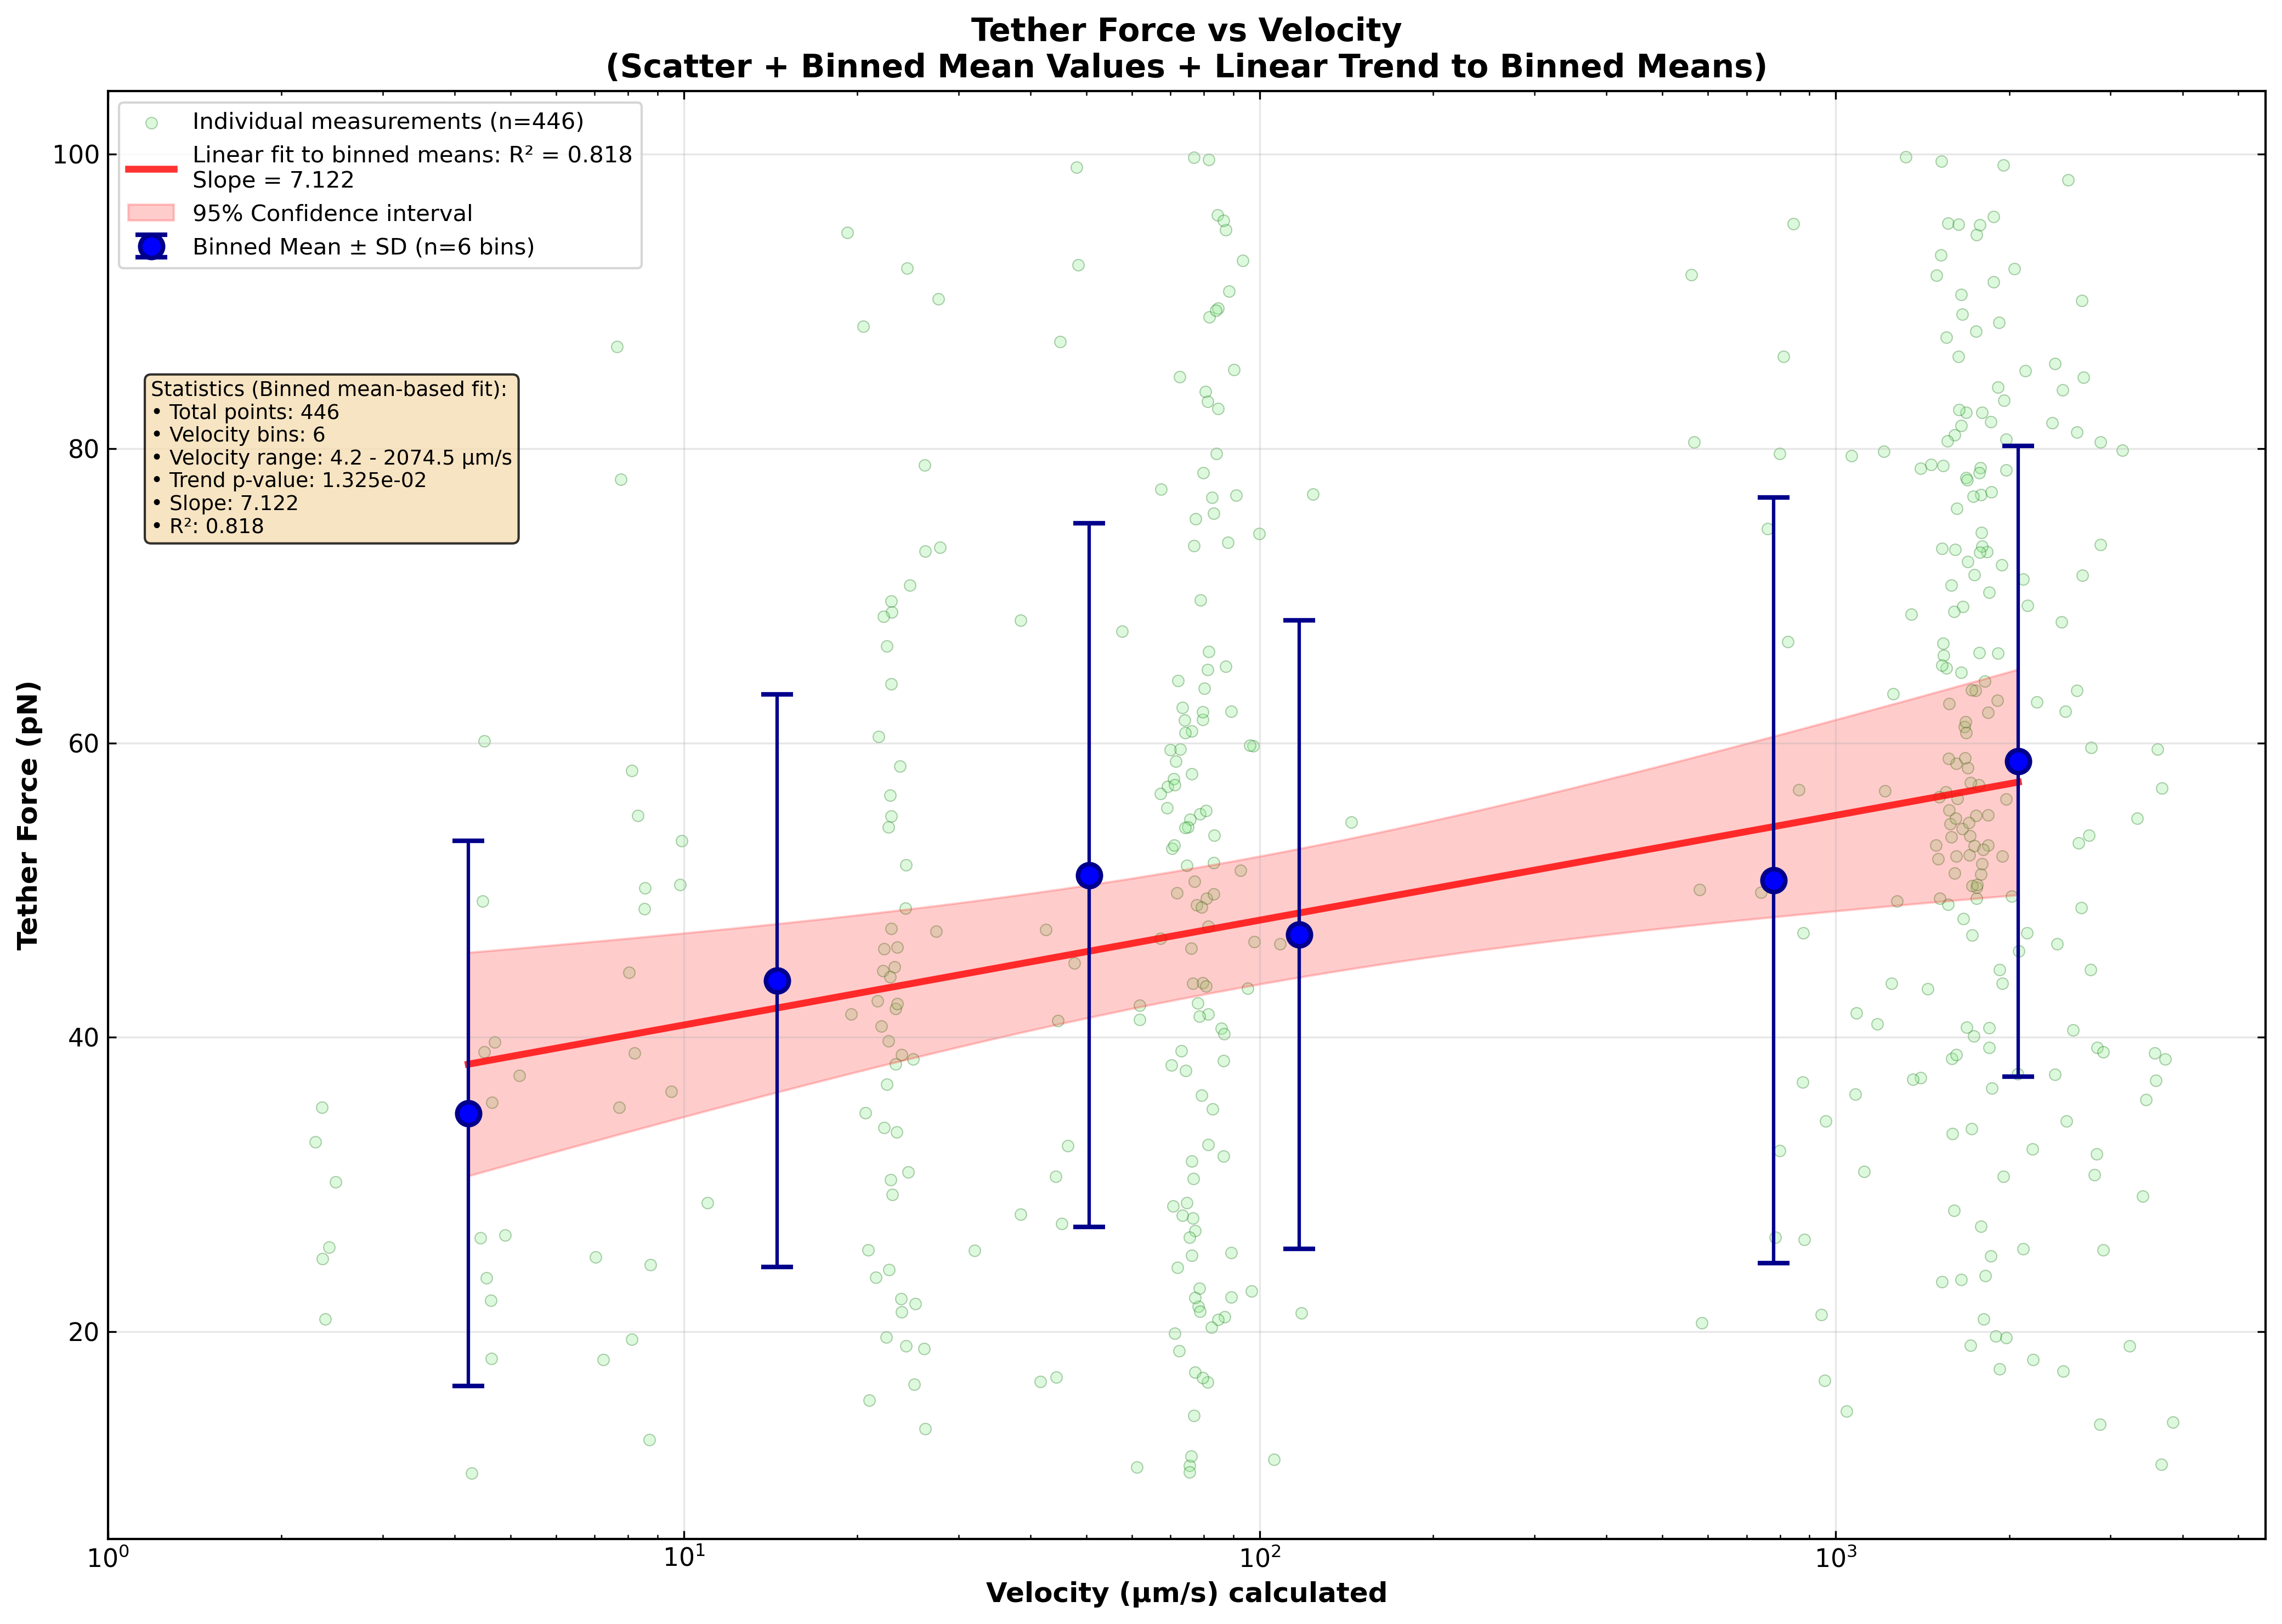

Force analysis complete:
  - Individual data points: 446
  - Velocity bins used for trend: 6
  - Linear correlation (binned means): R² = 0.818
  - Slope coefficient: 7.122
  - P-value: 1.325e-02
  - Bin information:
    Bin 1: 2.3-7.9 µm/s (23 points)
    Bin 2: 7.9-27.3 µm/s (65 points)
    Bin 3: 27.3-93.9 µm/s (131 points)
    Bin 4: 93.9-323.7 µm/s (11 points)
    Bin 5: 323.7-1115.7 µm/s (23 points)
    Bin 6: 1115.7-3845.2 µm/s (193 points)


In [9]:
# 2. Tether Force vs Velocity (Scatter + Linear Trend)
import scipy.stats as stats
from scipy.optimize import curve_fit

plt.figure(figsize=(14, 10), dpi=300)

# Filter and prepare force data
velocity_meta_clean = np.array(selected_velocity_meta)
delta_avg_clean = np.array(selected_delta_avg)

force_valid_mask = (
    ~np.isnan(velocity_meta_clean) & 
    ~np.isnan(delta_avg_clean) &
    (velocity_meta_clean != 0) &
    (delta_avg_clean != 0) &
    (np.abs(delta_avg_clean) > 10e-12) &   # >10 pN
    (np.abs(delta_avg_clean) < 100e-12)       # <1000 pN
)

velocity_force_filtered = velocity_meta_clean[force_valid_mask]
force_filtered = delta_avg_clean[force_valid_mask]

# Convert to log scale for analysis
velocity_log = np.log10(velocity_force_filtered)
force_log = np.abs(force_filtered) * 1e12

# Remove infinite values
finite_mask = np.isfinite(velocity_log) & np.isfinite(force_log)
velocity_log_clean = velocity_log[finite_mask]
force_log_clean = force_log[finite_mask]
velocity_clean = velocity_force_filtered[finite_mask]

# Create DataFrame for analysis
force_df = pd.DataFrame({
    'velocity': velocity_clean,
    'velocity_log': velocity_log_clean,
    'force_log': force_log_clean
})

# Main plot
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)

# 1. Scatter plot of all data points 
ax.scatter(force_df['velocity'], force_df['force_log'], 
          alpha=0.3, s=25, color='lightgreen', edgecolors='darkgreen', linewidth=0.5,
          label=f'Individual measurements (n={len(force_df)})')

# 2. Create velocity bins and calculate means and standard deviations
# Define velocity bin edges (log-spaced for better distribution)
velocity_min = force_df['velocity'].min()
velocity_max = force_df['velocity'].max()
num_velocity_bins = 6  # Adjust this number to control binning

# Create log-spaced bin edges
velocity_bin_edges = np.logspace(np.log10(velocity_min), np.log10(velocity_max), num_velocity_bins + 1)

# Assign each point to a velocity bin
force_df['velocity_bin_idx'] = np.digitize(force_df['velocity'], velocity_bin_edges) - 1
force_df['velocity_bin_idx'] = np.clip(force_df['velocity_bin_idx'], 0, num_velocity_bins - 1)

# Create bin labels for display
velocity_bin_labels = []
for i in range(num_velocity_bins):
    label = f"{velocity_bin_edges[i]:.1f}-{velocity_bin_edges[i+1]:.1f} µm/s"
    velocity_bin_labels.append(label)

# Add bin labels to dataframe
force_df['velocity_bin_label'] = [velocity_bin_labels[idx] for idx in force_df['velocity_bin_idx']]

# Calculate binned means and standard deviations
means_df = force_df.groupby('velocity_bin_idx').agg(
    velocity_mean=('velocity', 'mean'),
    velocity_bin_center=('velocity', lambda x: np.sqrt(x.min() * x.max())),  # Geometric mean for log scale
    force_mean=('force_log', 'mean'),
    force_std=('force_log', 'std'),
    force_count=('force_log', 'count'),
    bin_label=('velocity_bin_label', 'first')
).reset_index()

# Filter out bins with too few points
means_df = means_df[means_df['force_count'] >= 3]

# Plot means with error bars (standard deviation) using bin centers
ax.errorbar(means_df['velocity_bin_center'], means_df['force_mean'], 
           yerr=means_df['force_std'], 
           fmt='o', color='blue', markersize=10, markeredgecolor='darkblue', 
           markeredgewidth=2, ecolor='darkblue', capsize=7, capthick=2,
           label=f'Binned Mean ± SD (n={len(means_df)} bins)', zorder=5)

# 3. Fit linear trend to binned means only
if len(means_df) > 3:
    # Linear regression in log-log space on binned means
    vel_log_means = np.log10(means_df['velocity_bin_center'])
    force_log_means = means_df['force_mean']
    
    slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(
        vel_log_means, force_log_means)
    
    # Generate trend line
    vel_min = max(means_df['velocity_bin_center'].min(), 1)
    vel_max = means_df['velocity_bin_center'].max()
    vel_trend = np.logspace(np.log10(vel_min), np.log10(vel_max), 100)
    force_trend = intercept + slope_coeff * np.log10(vel_trend)
    
    ax.plot(vel_trend, force_trend, 'r-', linewidth=3, alpha=0.8,
           label=f'Linear fit to binned means: R² = {r_value**2:.3f}\nSlope = {slope_coeff:.3f}')
    
    # Add confidence interval for binned means fit
    from scipy import stats as scipy_stats
    n = len(means_df)
    t_val = scipy_stats.t.ppf(0.975, n-2)  # 95% confidence
    
    residuals = force_log_means - (intercept + slope_coeff * vel_log_means)
    mse = np.sum(residuals**2) / (n-2)
    
    vel_log_trend = np.log10(vel_trend)
    se_trend = np.sqrt(mse * (1/n + (vel_log_trend - np.mean(vel_log_means))**2 / 
                             np.sum((vel_log_means - np.mean(vel_log_means))**2)))
    
    ci_lower = force_trend - t_val * se_trend
    ci_upper = force_trend + t_val * se_trend
    
    ax.fill_between(vel_trend, ci_lower, ci_upper, alpha=0.2, color='red',
                   label='95% Confidence interval')

# Formatting
ax.set_xlabel("Velocity (µm/s) calculated", fontsize=12, fontweight='bold')
ax.set_ylabel("Tether Force (pN)", fontsize=12, fontweight='bold')
ax.set_title("Tether Force vs Velocity\n(Scatter + Binned Mean Values + Linear Trend to Binned Means)", 
            fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Add statistics text
stats_text = f"""Statistics (Binned mean-based fit):
• Total points: {len(force_df)}
• Velocity bins: {len(means_df)}
• Velocity range: {means_df['velocity_bin_center'].min():.1f} - {means_df['velocity_bin_center'].max():.1f} µm/s
• Trend p-value: {p_value:.3e}
• Slope: {slope_coeff:.3f}
• R²: {r_value**2:.3f}"""

ax.text(0.02, 0.8, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.tight_layout()
plt.xlim(left = 10e-1)
plt.show()

print(f"Force analysis complete:")
print(f"  - Individual data points: {len(force_df)}")
print(f"  - Velocity bins used for trend: {len(means_df)}")
print(f"  - Linear correlation (binned means): R² = {r_value**2:.3f}")
print(f"  - Slope coefficient: {slope_coeff:.3f}")
print(f"  - P-value: {p_value:.3e}")
print(f"  - Bin information:")
for i, row in means_df.iterrows():
    print(f"    Bin {i+1}: {row['bin_label']} ({row['force_count']} points)")

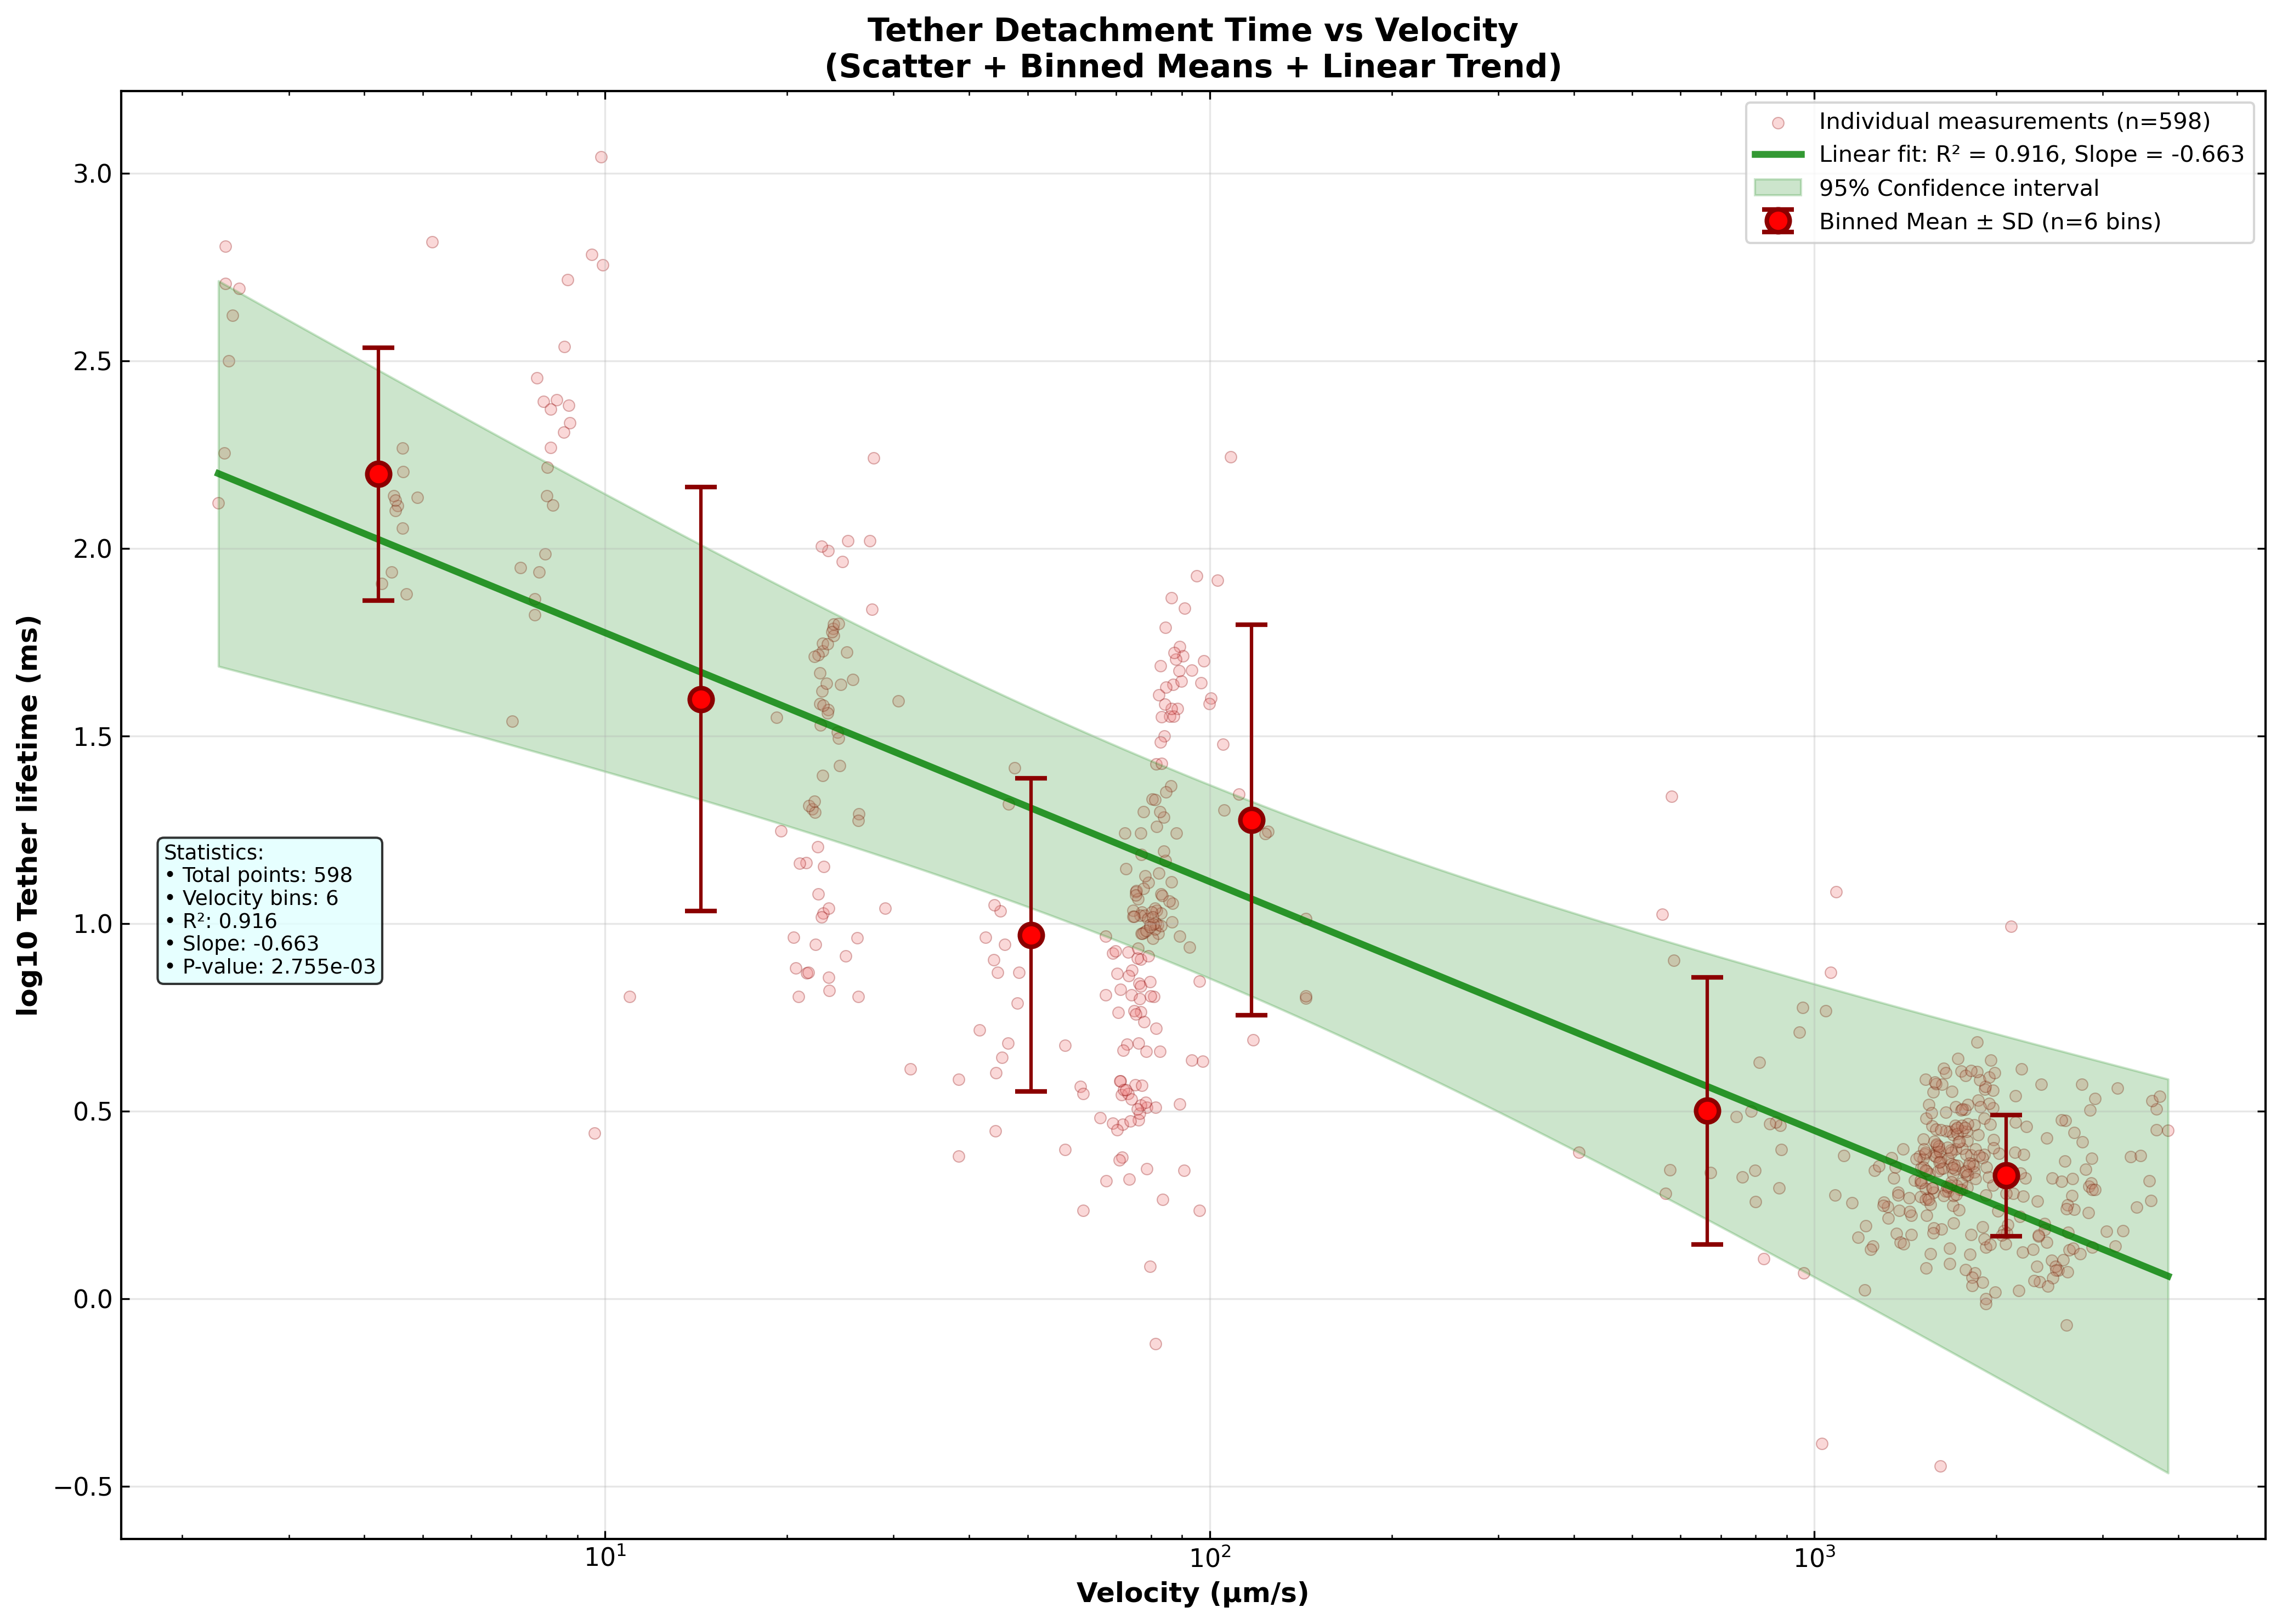

Time analysis: 598 points, 6 bins


In [10]:
# 3. Detachment Time vs Velocity (Combined Analysis with Binned Means)
import warnings
import scipy.stats as stats
from scipy import stats as scipy_stats
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Filter and prepare time data
velocity_filtered = np.array(filtered_velocity_meta_clean)
time_filtered = np.array(filtered_tether_lifetime_s_array_nan)

# Basic data filtering
valid_mask = (
    ~np.isnan(velocity_filtered) & 
    ~np.isnan(time_filtered) &
    (velocity_filtered > 1e-6) &
    (time_filtered > 0)
)

velocity_filtered = velocity_filtered[valid_mask]
time_filtered = time_filtered[valid_mask]
time_log = safe_log10(time_filtered * 1e3)  # Convert to ms

# Remove infinite values
finite_mask = np.isfinite(time_log)
velocity_filtered = velocity_filtered[finite_mask]
time_log = time_log[finite_mask]

# Create DataFrame
time_df = pd.DataFrame({
    'velocity': velocity_filtered,
    'time_log': time_log
})

# Create main plot
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)

# 1. Scatter plot of all data points
ax.scatter(time_df['velocity'], time_df['time_log'], 
          alpha=0.3, s=25, color='lightcoral', edgecolors='darkred', linewidth=0.5,
          label=f'Individual measurements (n={len(time_df)})')

# 2. Create velocity bins and calculate means
num_bins = 6
velocity_min, velocity_max = time_df['velocity'].min(), time_df['velocity'].max()
bin_edges = np.logspace(np.log10(velocity_min), np.log10(velocity_max), num_bins + 1)

# Assign bins and calculate means
time_df['bin_idx'] = np.digitize(time_df['velocity'], bin_edges) - 1
time_df['bin_idx'] = np.clip(time_df['bin_idx'], 0, num_bins - 1)

means_df = time_df.groupby('bin_idx').agg(
    velocity_center=('velocity', lambda x: np.sqrt(x.min() * x.max())),
    time_mean=('time_log', 'mean'),
    time_std=('time_log', 'std'),
    count=('time_log', 'count')
).reset_index()

# Filter bins with enough data
means_df = means_df[means_df['count'] >= 3]

# 3. Plot means with error bars
if len(means_df) > 0:
    ax.errorbar(means_df['velocity_center'], means_df['time_mean'], 
               yerr=means_df['time_std'], 
               fmt='o', color='red', markersize=10, markeredgecolor='darkred', 
               markeredgewidth=2, ecolor='darkred', capsize=7, capthick=2,
               label=f'Binned Mean ± SD (n={len(means_df)} bins)', zorder=5)

# 4. Fit linear trend to means
if len(means_df) >= 3:
    x_log = np.log10(means_df['velocity_center'])
    y_log = means_df['time_mean']
    
    slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(x_log, y_log)
    
    # Generate and plot trend line
    x_trend = np.logspace(np.log10(velocity_min), np.log10(velocity_max), 100)
    y_trend = intercept + slope_coeff * np.log10(x_trend)
    
    ax.plot(x_trend, y_trend, 'green', linewidth=3, alpha=0.8,
           label=f'Linear fit: R² = {r_value**2:.3f}, Slope = {slope_coeff:.3f}')
    
    # Add confidence interval
    n = len(means_df)
    t_val = scipy_stats.t.ppf(0.975, n-2)
    residuals = y_log - (intercept + slope_coeff * x_log)
    mse = np.sum(residuals**2) / (n-2)
    
    x_log_trend = np.log10(x_trend)
    se_trend = np.sqrt(mse * (1/n + (x_log_trend - np.mean(x_log))**2 / 
                             np.sum((x_log - np.mean(x_log))**2)))
    
    ci_lower = y_trend - t_val * se_trend
    ci_upper = y_trend + t_val * se_trend
    
    ax.fill_between(x_trend, ci_lower, ci_upper, alpha=0.2, color='green',
                   label='95% Confidence interval')
else:
    slope_coeff, r_value, p_value = np.nan, np.nan, np.nan

# Formatting
ax.set_xlabel("Velocity (µm/s)", fontsize=12, fontweight='bold')
ax.set_ylabel("log10 Tether lifetime (ms)", fontsize=12, fontweight='bold')
ax.set_title("Tether Detachment Time vs Velocity\n(Scatter + Binned Means + Linear Trend)", 
            fontsize=14, fontweight='bold')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Statistics text
if not np.isnan(r_value):
    stats_text = f"""Statistics:
• Total points: {len(time_df)}
• Velocity bins: {len(means_df)}
• R²: {r_value**2:.3f}
• Slope: {slope_coeff:.3f}
• P-value: {p_value:.3e}"""
else:
    stats_text = f"""Statistics:
• Total points: {len(time_df)}
• Insufficient data for trend"""

ax.text(0.02, 0.48, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Time analysis: {len(time_df)} points, {len(means_df)} bins")

<Figure size 4200x3000 with 0 Axes>

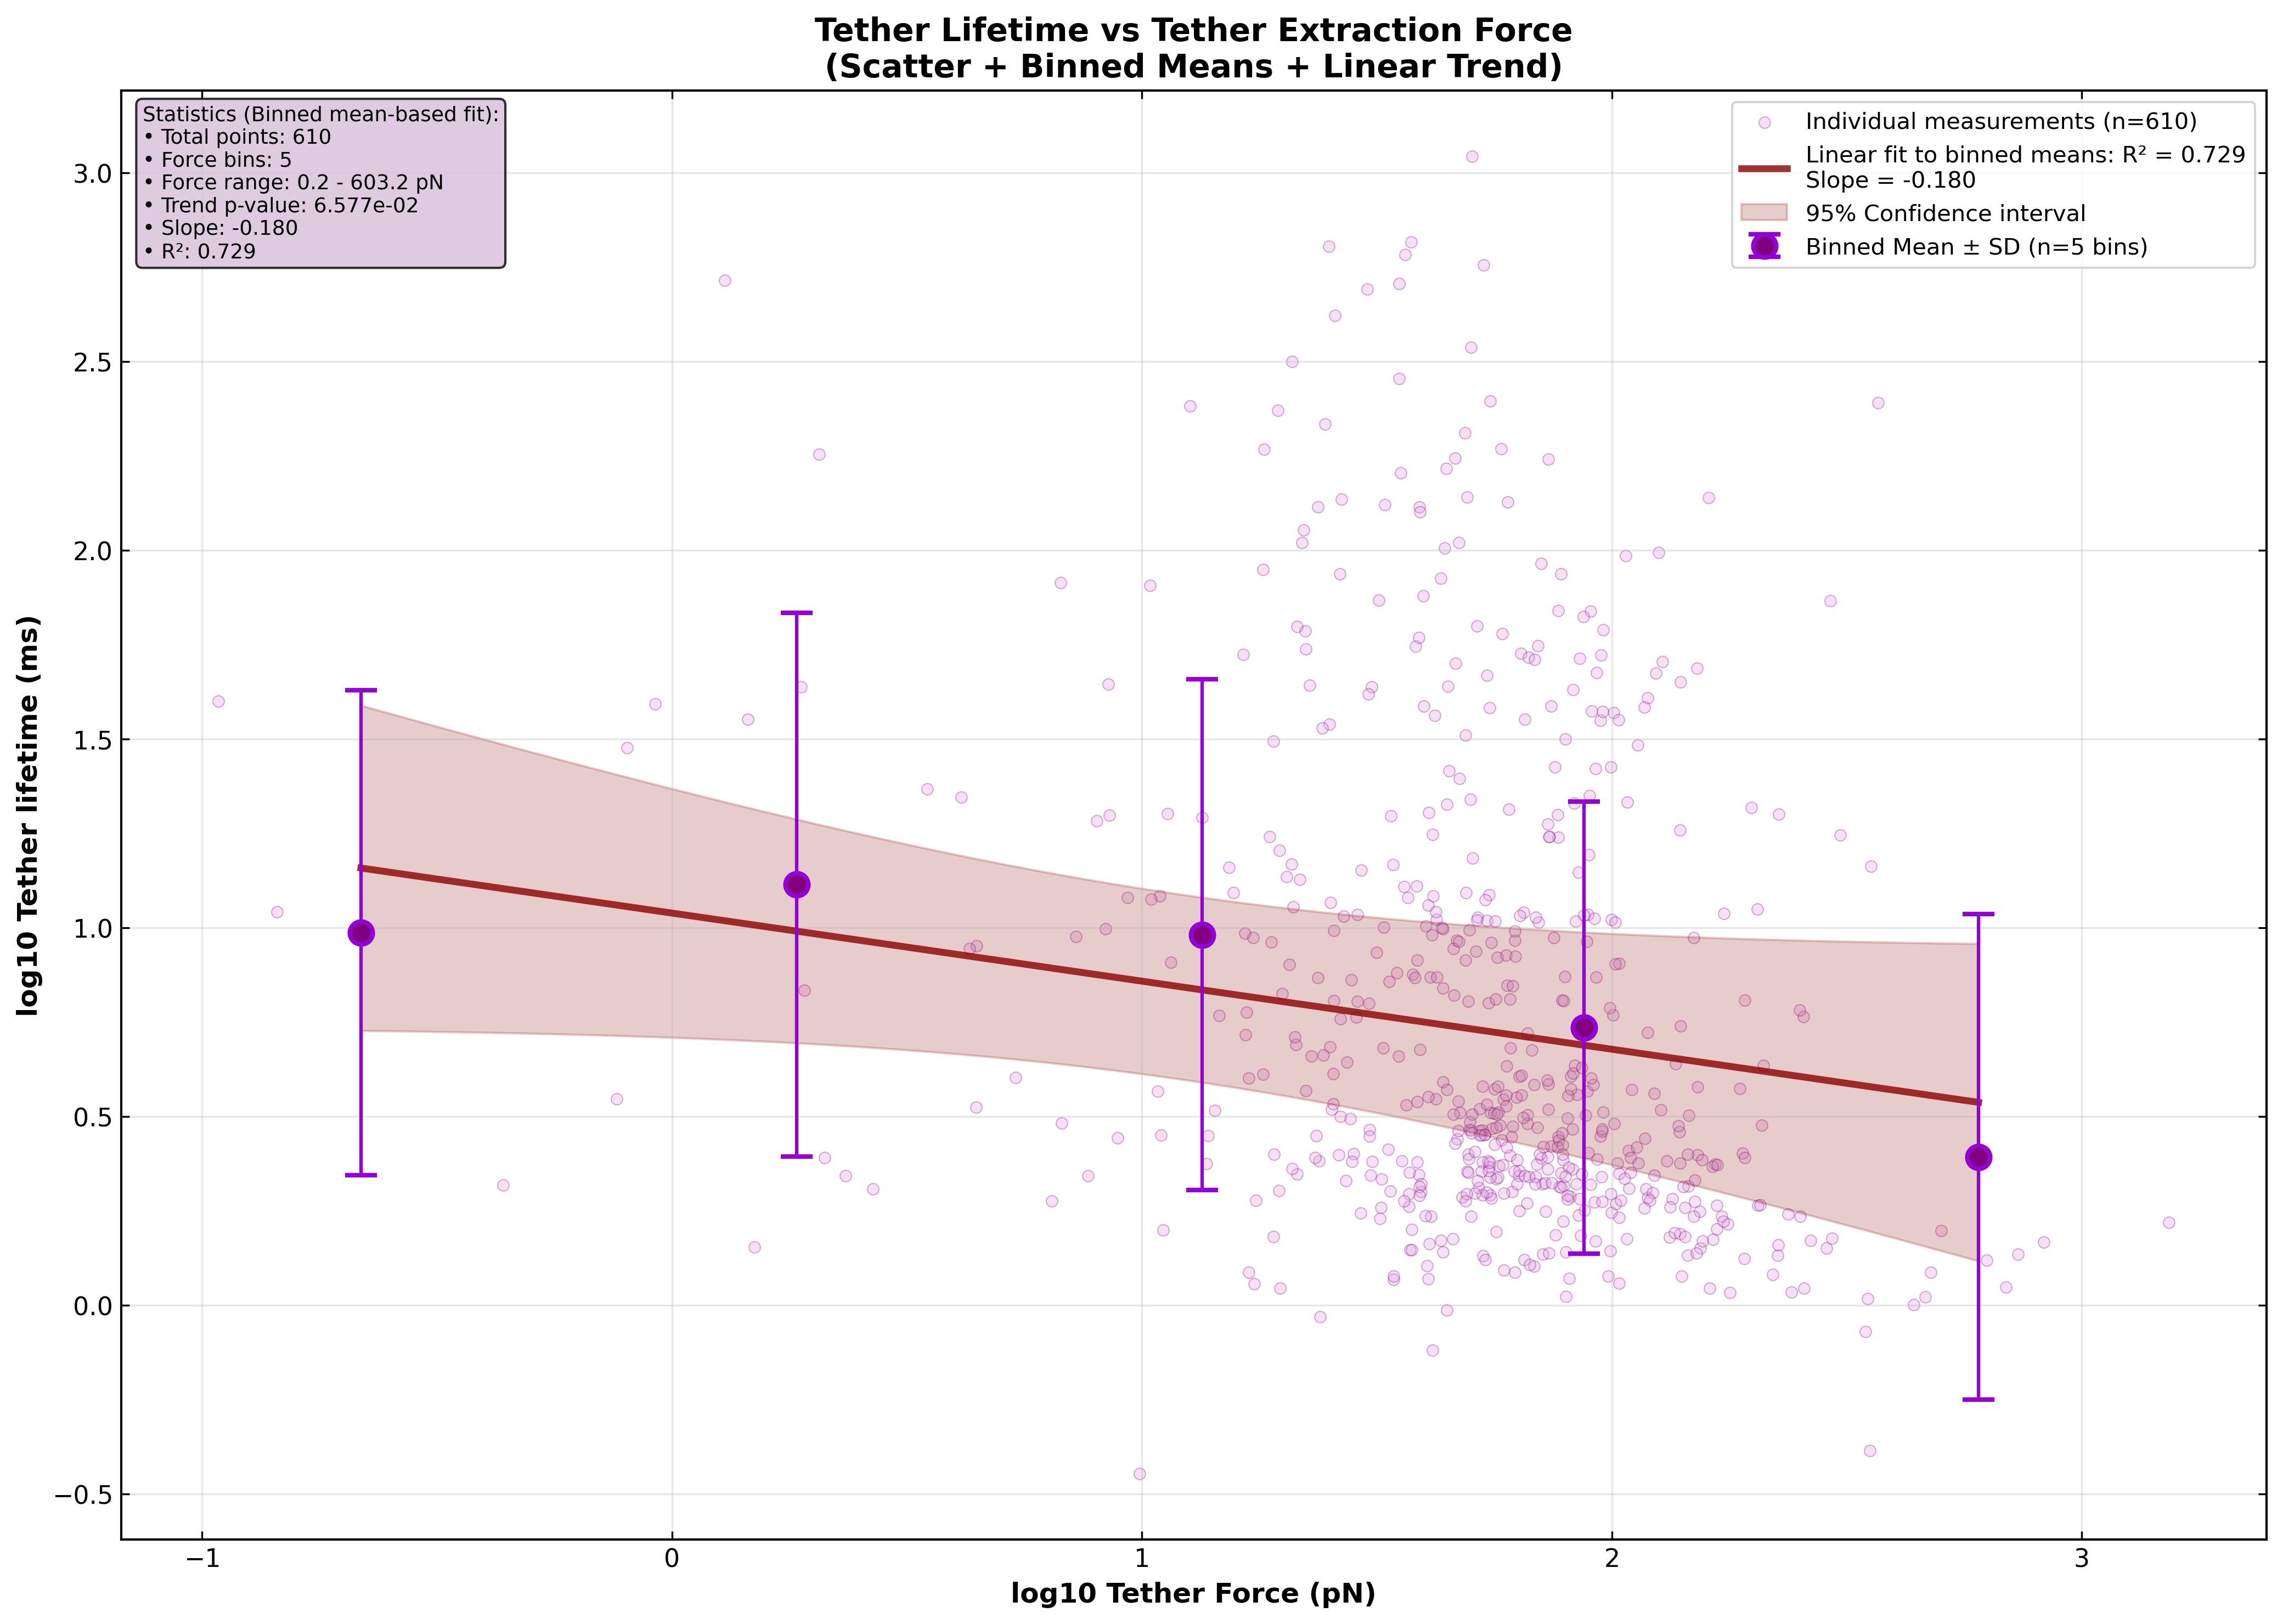

Force-lifetime analysis complete:
  - Individual data points: 610
  - Force bins used for trend: 5
  - Linear correlation (binned means): R² = 0.729
  - Slope coefficient: -0.180
  - P-value: 6.577e-02


In [11]:
# 5. Tether lifetime vs tether extraction force (Combined Analysis with Binned Means)
plt.figure(figsize=(14, 10), dpi=300)

# Create DataFrame for analysis
force_bins_df = pd.DataFrame({
    'force_log': safe_log10(tether_force_array* 1e12),  # Convert to pN
    'lifetime_log': safe_log10(tether_lifetime_s_array * 1e3)
})

# Remove invalid log values
force_bins_df = force_bins_df[np.isfinite(force_bins_df['force_log']) & np.isfinite(force_bins_df['lifetime_log'])]

# Main plot
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)

# 1. Scatter plot of all data points
ax.scatter(force_bins_df['force_log'], force_bins_df['lifetime_log'], 
          alpha=0.3, s=25, color='plum', edgecolors='purple', linewidth=0.5,
          label=f'Individual measurements (n={len(force_bins_df)})')

# 2. Create force bins and calculate means and standard deviations
force_min = force_bins_df['force_log'].min()
force_max = force_bins_df['force_log'].max()
num_force_bins = 5

# Create evenly spaced bin edges for force
force_bin_edges = np.linspace(force_min, force_max, num_force_bins + 1)

# Assign each point to a force bin
force_bins_df['force_bin_idx'] = np.digitize(force_bins_df['force_log'], force_bin_edges) - 1
force_bins_df['force_bin_idx'] = np.clip(force_bins_df['force_bin_idx'], 0, num_force_bins - 1)

# Calculate binned means and standard deviations
means_df_force = force_bins_df.groupby('force_bin_idx').agg(
    force_mean=('force_log', 'mean'),
    force_bin_center=('force_log', lambda x: (x.min() + x.max()) / 2),
    lifetime_mean=('lifetime_log', 'mean'),
    lifetime_std=('lifetime_log', 'std'),
    lifetime_count=('lifetime_log', 'count')
).reset_index()

# Filter out bins with too few points
means_df_force = means_df_force[means_df_force['lifetime_count'] >= 3]

# Plot means with error bars
ax.errorbar(means_df_force['force_bin_center'], means_df_force['lifetime_mean'], 
           yerr=means_df_force['lifetime_std'], 
           fmt='o', color='purple', markersize=10, markeredgecolor='darkviolet', 
           markeredgewidth=2, ecolor='darkviolet', capsize=7, capthick=2,
           label=f'Binned Mean ± SD (n={len(means_df_force)} bins)', zorder=5)

# 3. Fit linear trend to binned means
if len(means_df_force) > 3:
    force_log_means = means_df_force['force_bin_center']
    lifetime_log_means = means_df_force['lifetime_mean']
    
    slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(
        force_log_means, lifetime_log_means)
    
    # Generate trend line
    force_trend = np.linspace(means_df_force['force_bin_center'].min(), 
                             means_df_force['force_bin_center'].max(), 100)
    lifetime_trend = intercept + slope_coeff * force_trend
    
    ax.plot(force_trend, lifetime_trend, 'darkred', linewidth=3, alpha=0.8,
           label=f'Linear fit to binned means: R² = {r_value**2:.3f}\nSlope = {slope_coeff:.3f}')
    
    # Add confidence interval
    n = len(means_df_force)
    t_val = scipy_stats.t.ppf(0.975, n-2)
    residuals = lifetime_log_means - (intercept + slope_coeff * force_log_means)
    mse = np.sum(residuals**2) / (n-2)
    
    se_trend = np.sqrt(mse * (1/n + (force_trend - np.mean(force_log_means))**2 / 
                             np.sum((force_log_means - np.mean(force_log_means))**2)))
    
    ci_lower = lifetime_trend - t_val * se_trend
    ci_upper = lifetime_trend + t_val * se_trend
    
    ax.fill_between(force_trend, ci_lower, ci_upper, alpha=0.2, color='darkred',
                   label='95% Confidence interval')

# Formatting
ax.set_xlabel("log10 Tether Force (pN)", fontsize=12, fontweight='bold')
ax.set_ylabel("log10 Tether lifetime (ms)", fontsize=12, fontweight='bold')
ax.set_title("Tether Lifetime vs Tether Extraction Force\n(Scatter + Binned Means + Linear Trend)", 
            fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Add statistics text
stats_text = f"""Statistics (Binned mean-based fit):
• Total points: {len(force_bins_df)}
• Force bins: {len(means_df_force)}
• Force range: {10**means_df_force['force_bin_center'].min():.1f} - {10**means_df_force['force_bin_center'].max():.1f} pN
• Trend p-value: {p_value:.3e}
• Slope: {slope_coeff:.3f}
• R²: {r_value**2:.3f}"""

ax.text(0.01, 0.99, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='thistle', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Force-lifetime analysis complete:")
print(f"  - Individual data points: {len(force_bins_df)}")
print(f"  - Force bins used for trend: {len(means_df_force)}")
print(f"  - Linear correlation (binned means): R² = {r_value**2:.3f}")
print(f"  - Slope coefficient: {slope_coeff:.3f}")
print(f"  - P-value: {p_value:.3e}")

<Figure size 4200x3000 with 0 Axes>

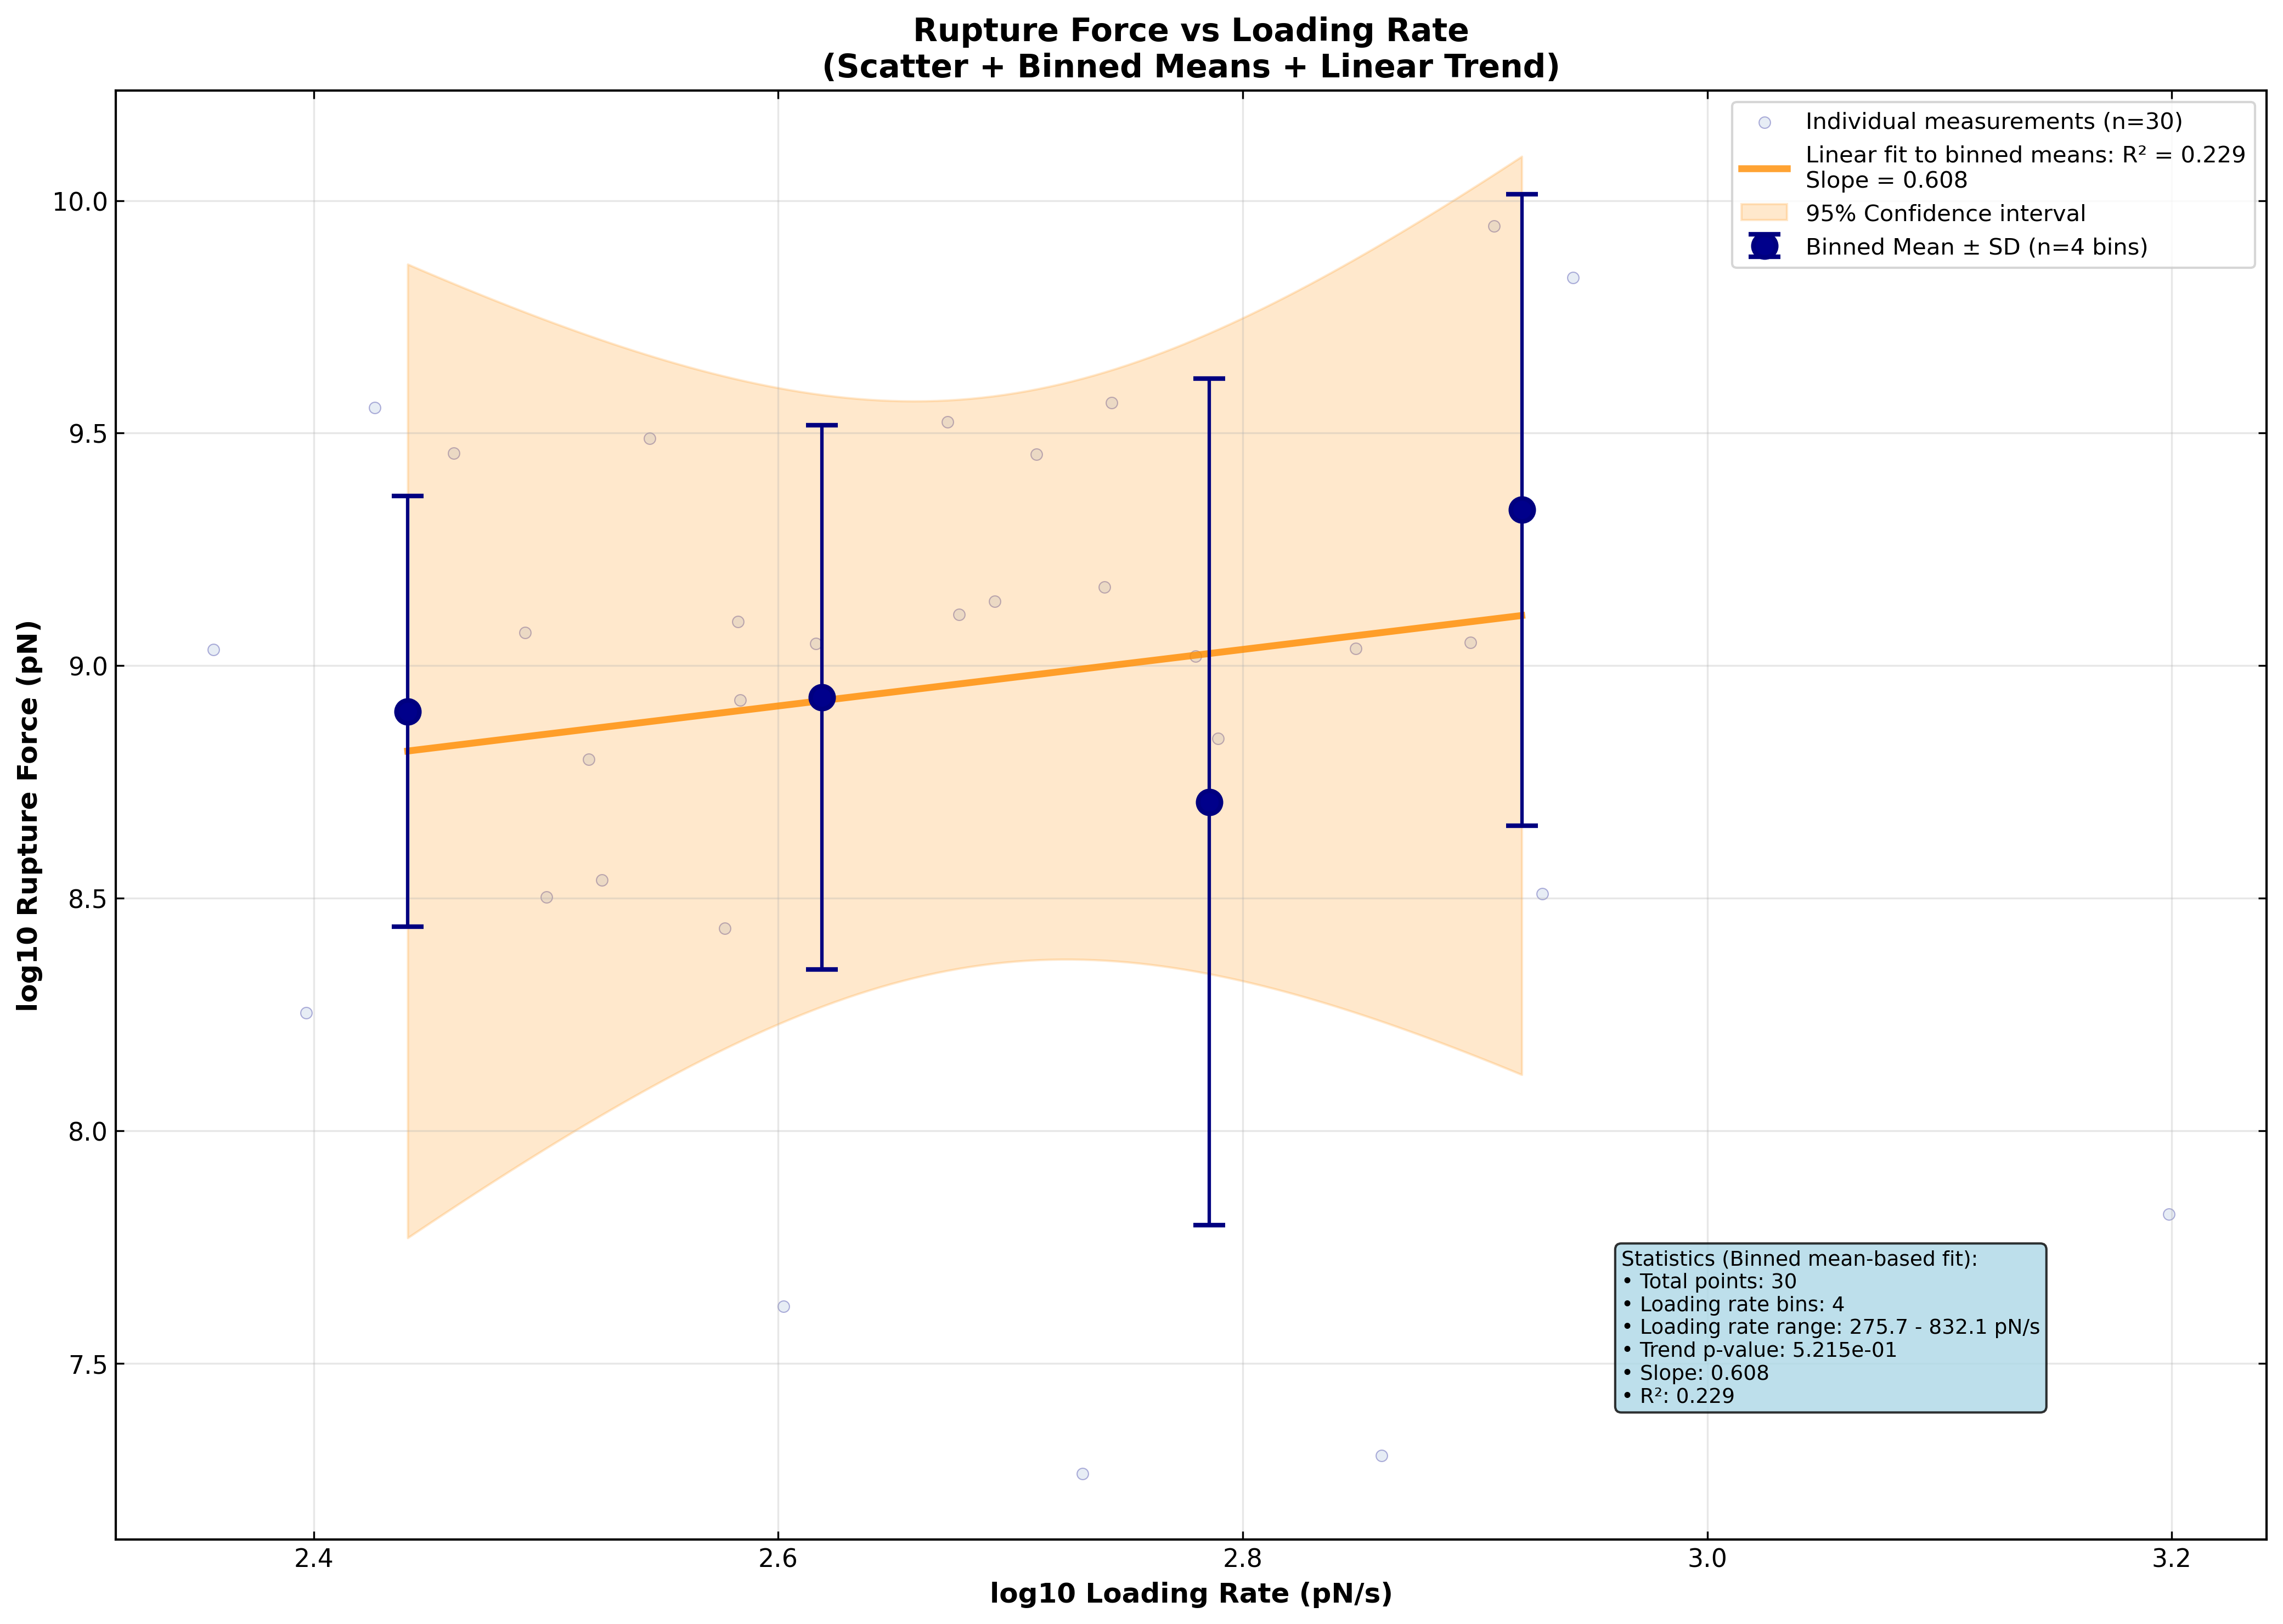

Loading rate analysis complete:
  - Individual data points: 30
  - Loading rate bins used for trend: 4
  - Linear correlation (binned means): R² = 0.229
  - Slope coefficient: 0.608
  - P-value: 5.215e-01


In [12]:
# 6. Rupture Force vs Loading Rate (Combined Analysis with Binned Means)
plt.figure(figsize=(14, 10), dpi=300)

# Create DataFrame for analysis
loading_bins_df = pd.DataFrame({
    'loading_rate_log': safe_log10(loading_rate_sorted * 1e12),  # Convert to pN/s
    'rupture_slope_log': safe_log10(rupture_slope_array_clean * 1e12)  # Convert to pN
})

# Remove invalid log values
loading_bins_df = loading_bins_df[np.isfinite(loading_bins_df['loading_rate_log']) & np.isfinite(loading_bins_df['rupture_slope_log'])]

# Main plot
fig, ax = plt.subplots(figsize=(14, 10), dpi=300)

# 1. Scatter plot of all data points
ax.scatter(loading_bins_df['loading_rate_log'], loading_bins_df['rupture_slope_log'], 
          alpha=0.3, s=25, color='lightsteelblue', edgecolors='darkblue', linewidth=0.5,
          label=f'Individual measurements (n={len(loading_bins_df)})')

# 2. Create loading rate bins and calculate means and standard deviations
loading_min = loading_bins_df['loading_rate_log'].min()
loading_max = loading_bins_df['loading_rate_log'].max()
num_loading_bins = 5

# Create evenly spaced bin edges for loading rate
loading_bin_edges = np.linspace(loading_min, loading_max, num_loading_bins + 1)

# Assign each point to a loading rate bin
loading_bins_df['loading_bin_idx'] = np.digitize(loading_bins_df['loading_rate_log'], loading_bin_edges) - 1
loading_bins_df['loading_bin_idx'] = np.clip(loading_bins_df['loading_bin_idx'], 0, num_loading_bins - 1)

# Calculate binned means and standard deviations
means_df_loading = loading_bins_df.groupby('loading_bin_idx').agg(
    loading_mean=('loading_rate_log', 'mean'),
    loading_bin_center=('loading_rate_log', lambda x: (x.min() + x.max()) / 2),
    force_mean=('rupture_slope_log', 'mean'),
    force_std=('rupture_slope_log', 'std'),
    force_count=('rupture_slope_log', 'count')
).reset_index()

# Filter out bins with too few points
means_df_loading = means_df_loading[means_df_loading['force_count'] >= 3]

# Plot means with error bars
ax.errorbar(means_df_loading['loading_bin_center'], means_df_loading['force_mean'], 
           yerr=means_df_loading['force_std'], 
           fmt='o', color='darkblue', markersize=10, markeredgecolor='navy', 
           markeredgewidth=2, ecolor='navy', capsize=7, capthick=2,
           label=f'Binned Mean ± SD (n={len(means_df_loading)} bins)', zorder=5)

# 3. Fit linear trend to binned means
if len(means_df_loading) > 3:
    loading_log_means = means_df_loading['loading_bin_center']
    rupture_slope_log_means = means_df_loading['force_mean']
    
    slope_coeff, intercept, r_value, p_value, std_err = stats.linregress(
        loading_log_means, rupture_slope_log_means)
    
    # Generate trend line
    loading_trend = np.linspace(means_df_loading['loading_bin_center'].min(), 
                               means_df_loading['loading_bin_center'].max(), 100)
    force_trend = intercept + slope_coeff * loading_trend
    
    ax.plot(loading_trend, force_trend, 'darkorange', linewidth=3, alpha=0.8,
           label=f'Linear fit to binned means: R² = {r_value**2:.3f}\nSlope = {slope_coeff:.3f}')
    
    # Add confidence interval
    n = len(means_df_loading)
    t_val = scipy_stats.t.ppf(0.975, n-2)
    residuals = rupture_slope_log_means - (intercept + slope_coeff * loading_log_means)
    mse = np.sum(residuals**2) / (n-2)
    
    se_trend = np.sqrt(mse * (1/n + (loading_trend - np.mean(loading_log_means))**2 / 
                             np.sum((loading_log_means - np.mean(loading_log_means))**2)))
    
    ci_lower = force_trend - t_val * se_trend
    ci_upper = force_trend + t_val * se_trend
    
    ax.fill_between(loading_trend, ci_lower, ci_upper, alpha=0.2, color='darkorange',
                   label='95% Confidence interval')

# Formatting
ax.set_xlabel("log10 Loading Rate (pN/s)", fontsize=12, fontweight='bold')
ax.set_ylabel("log10 Rupture Force (pN)", fontsize=12, fontweight='bold')
ax.set_title("Rupture Force vs Loading Rate\n(Scatter + Binned Means + Linear Trend)", 
            fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)

# Add statistics text
stats_text = f"""Statistics (Binned mean-based fit):
• Total points: {len(loading_bins_df)}
• Loading rate bins: {len(means_df_loading)}
• Loading rate range: {10**means_df_loading['loading_bin_center'].min():.1f} - {10**means_df_loading['loading_bin_center'].max():.1f} pN/s
• Trend p-value: {p_value:.3e}
• Slope: {slope_coeff:.3f}
• R²: {r_value**2:.3f}"""

ax.text(0.7, 0.2, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"Loading rate analysis complete:")
print(f"  - Individual data points: {len(loading_bins_df)}")
print(f"  - Loading rate bins used for trend: {len(means_df_loading)}")
print(f"  - Linear correlation (binned means): R² = {r_value**2:.3f}")
print(f"  - Slope coefficient: {slope_coeff:.3f}")
print(f"  - P-value: {p_value:.3e}")